In [1]:
import os
import pygmt
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import bordado as bd
import boule as bl
import harmonica as hm
import verde as vd
import itertools
from scipy.interpolate import griddata

import spherical as sph

In [2]:
def save_fit_results(model, filename="fit_results"):
    attrs = {}
    for key in ["residuals_", "dipole_moments_", "window_centers_", "source_coordinates_"]:
        if hasattr(model, key):
            attrs[key] = getattr(model, key)
    np.savez(f"{filename}.npz", **attrs, allow_pickle=True)

def load_fit_results(model, filename="fit_results"):
    data = np.load(f"{filename}.npz", allow_pickle=True)
    for key in data.files:
        value = data[key]
        if key == "source_coordinates_":
            value = tuple(value)
        setattr(model, key, value)
    return model

def deg_to_km(spacing_km):
    spacing_deg = spacing_km / 111.11
    return spacing_deg

def save_predict_results(coordinates, prediction, filename="predict_results"):

    np.savez(
        f"{filename}.npz",
        coordinates=coordinates,
        prediction=prediction,
        allow_pickle=True,
    )


def load_predict_results(filename="predict_results"):

    data = np.load(f"{filename}.npz", allow_pickle=True)

    coordinates = data["coordinates"]
    prediction = data["prediction"]

    return coordinates, prediction


In [3]:
caminho = "../data/parana-basin-magnetic-processed.csv"

df = pd.read_csv(caminho, sep=',', comment="#")
df.columns = ['FID','ESTACAO','LINHA','X','Y','LATITUDE','LONGITUDE','DATA','HORA','GPSALT','BARO',
              'MAGBRU','MAGCOM','MAGBASE','MAGCOR','MAGNIV','MAGMIC','MAGIGRF','IGRF','MDT']

prefixos = ('19', '29', '39')
df = df[~df['LINHA'].astype(str).str.startswith(prefixos)].copy()

In [4]:
coordinates = (df['LONGITUDE'].values, df['LATITUDE'].values, df["GPSALT"].values)
mag = (df['MAGIGRF'].values)

In [ ]:
inclination, declination = -25, -20 

grid_spacing = 0.0023
window_size = 1.5

grid_coord = bd.grid_coordinates((-56.8, -46.5, -25, -14), spacing= grid_spacing, non_dimensional_coords=500)
print(deg_to_km(1))

0.00900009000090001


In [6]:
eqs_deep_full_loaded = sph.EquivalentSourcesMagGeod(damping=1e1, depth= 100e3)

eqs_deep_full_loaded = load_fit_results(eqs_deep_full_loaded, filename="eqs_deep_fit_full")

predicted_deep = eqs_deep_full_loaded.predict(grid_coord)

tfa_predicted_deep=hm.total_field_anomaly(
    predicted_deep,
    inclination,
    declination,
)

save_predict_results(
    grid_coord,
    predicted_deep,
    filename="eqs_deep_predict_grid_full"
)


predicted_scatter_deep = eqs_deep_full_loaded.predict(coordinates)

tfa_predicted_scatter_deep = hm.total_field_anomaly(
    predicted_scatter_deep,
    inclination,
    declination,
)

save_predict_results(
    coordinates,
    predicted_scatter_deep,
    filename="eqs_deep_predict_scatter_full"
)


In [7]:
%%time
eqs_shallow_full_loaded = sph.EquivalentSourcesMagGeodGB(
    block_size=grid_spacing,
    window_size=window_size,
    depth = 7e3,
    damping = 1e5
)

eqs_shallow_full_loaded = load_fit_results(eqs_shallow_full_loaded, filename="eqs_shallow_fit_full")

predicted_shallow = eqs_shallow_full_loaded.predict(grid_coord)

tfa_predicted_shallow=hm.total_field_anomaly(
    predicted_shallow,
    inclination,
    declination,
)

save_predict_results(
    grid_coord,
    predicted_shallow,
    filename="eqs_shallow_predict_grid_full"
)

predicted_scatter_shallow = eqs_shallow_full_loaded.predict(coordinates)

tfa_predicted_scatter_shallow = hm.total_field_anomaly(
    predicted_scatter_shallow,
    inclination,
    declination,
)

save_predict_results(
    coordinates,
    predicted_scatter_shallow,
    filename="eqs_shallow_predict_scatter_full"
)

CPU times: user 13h 48min 30s, sys: 1min 16s, total: 13h 49min 46s
Wall time: 1h 51min 54s


In [8]:
%%time
tfa_scatter = tfa_predicted_scatter_deep + tfa_predicted_scatter_shallow
tfa_grid = tfa_predicted_deep + tfa_predicted_shallow

total_field_anomaly_predicted = vd.make_xarray_grid(
    grid_coord,
    tfa_grid,
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

CPU times: user 38 ms, sys: 0 ns, total: 38 ms
Wall time: 36.6 ms


In [9]:
print(tfa_scatter.size)

1636695


In [ ]:
shapefile_brasil = "../data/BR_UF_2022/BR_UF_2022.shp"


required_extensions = ['.shp', '.shx', '.dbf']
base_name = os.path.splitext(shapefile_brasil)[0]

missing_files = []
for ext in required_extensions:
    file_path = f"{base_name}{ext}"
    if not os.path.exists(file_path):
        missing_files.append(file_path)

if missing_files:
    print(f"Erro: Os seguintes arquivos obrigatórios estão faltando: {', '.join(missing_files)}")
    exit()


try:
    brasil = gpd.read_file(shapefile_brasil)
except Exception as e:
    print(f"Erro ao carregar o shapefile: {e}")
    exit()



brasil_reduc = brasil.simplify(0.05)

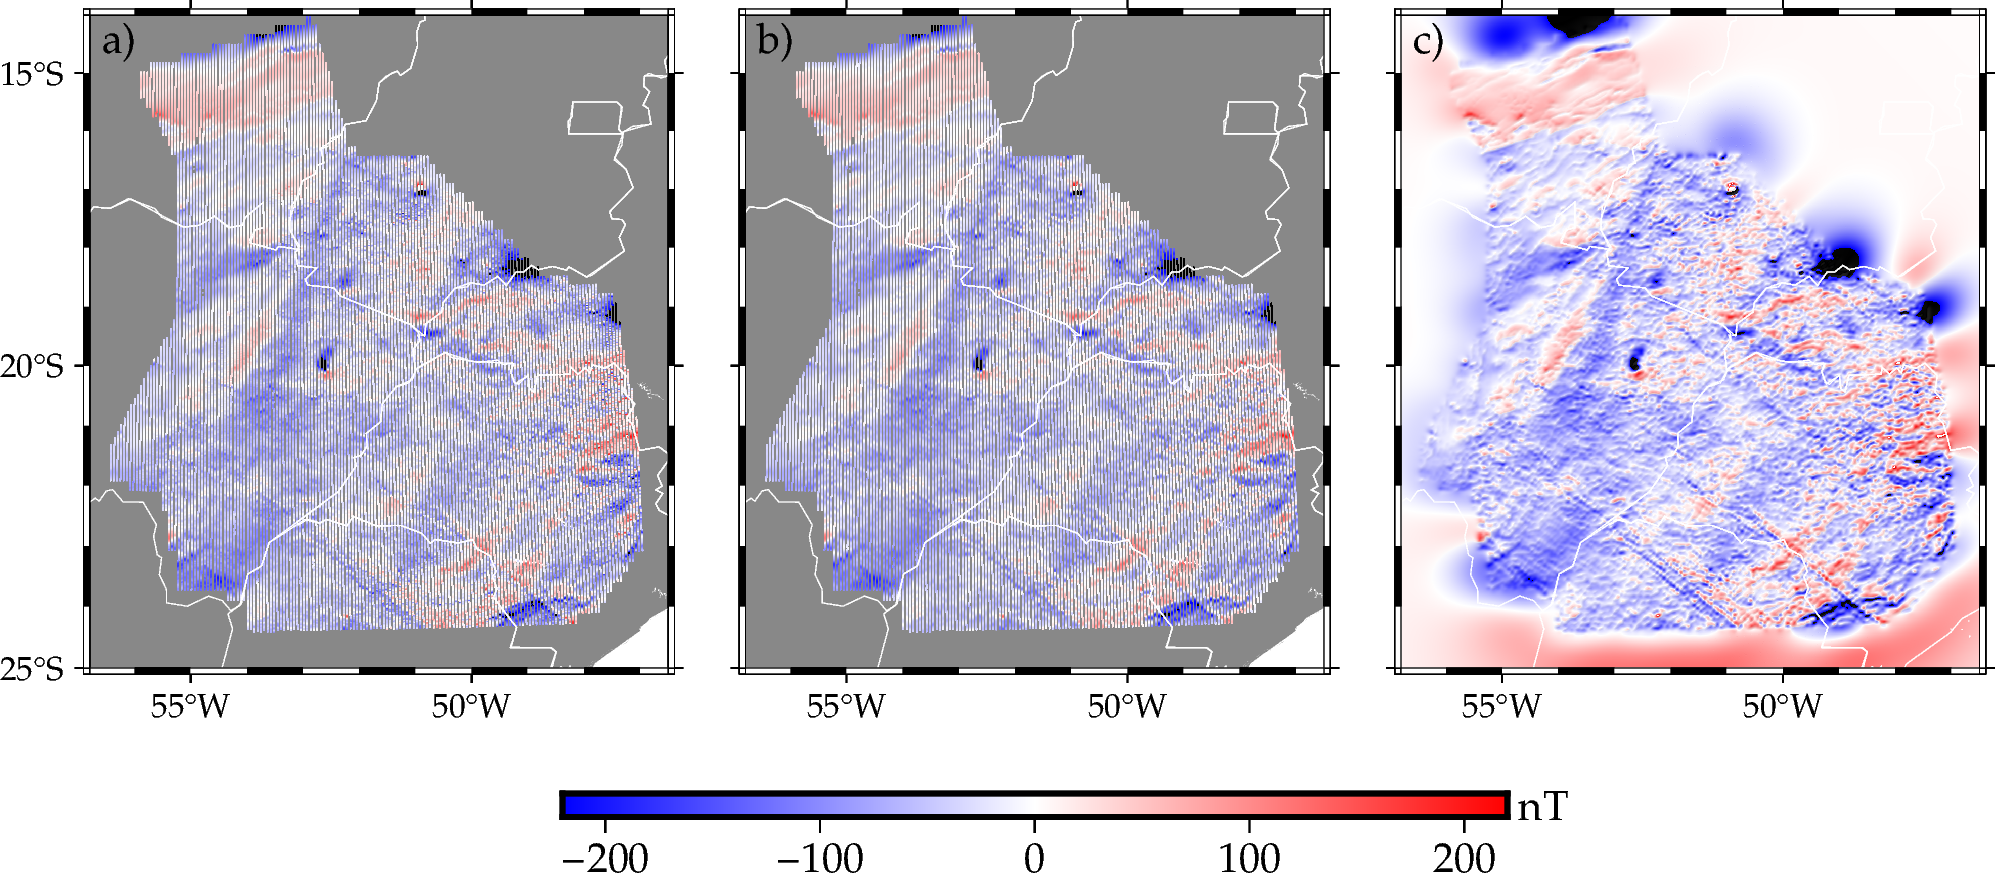

In [ ]:
region = [-56.8, -46.5, -25, -14]
scale = 220
fig = pygmt.Figure()

with pygmt.config(FONT="10p,Palatino-Roman",
    FONT_ANNOT="8p,Palatino-Roman",
    FONT_ANNOT_PRIMARY="8p,Palatino-Roman",
    FONT_ANNOT_SECONDARY="8p,Palatino-Roman",
    MAP_FRAME_WIDTH="1.5p",
    MAP_TITLE_OFFSET="-2p", ):

    pygmt.makecpt(cmap="polar", series=[-scale, scale])

    with fig.subplot(nrows=1,
            ncols=3,
            figsize=("16c", "6c"),
            autolabel="+jTL+o0.1/0.3c",
            margins='0.2c/.2c',
            sharex="b",
            sharey="l"):
        
        with fig.set_panel(panel=0):

            fig.coast(
                    land="#888888",
                    region = region,
                    projection="M?",
                )

            fig.plot(
                    x=df.LONGITUDE,
                    y=df.LATITUDE,
                    fill=df.MAGIGRF,
                    style="c0.01c",
                    cmap=True
            )

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )


        with fig.set_panel(panel=1):

            fig.coast(
                    land="#888888",
                    region = region,
                    projection="M?",
            )
            
            fig.plot(
                x=coordinates[0],
                y=coordinates[1],
                fill=tfa_scatter,
                style="c0.01c",
                projection="M?",
                cmap=True
            )

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )

        with fig.set_panel(panel=2):

            fig.coast(
                land="#888888",
                region = region,
                projection="M?",
            )

            fig.grdimage(
            grid=total_field_anomaly_predicted,
            region=region,
            projection="M?",  
            cmap=True,
            shading="+nt0.15",
            )       

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )


pygmt.config(FONT_ANNOT_PRIMARY="10p,Palatino-Roman", FONT_ANNOT_SECONDARY="10p,Palatino-Roman")
fig.colorbar(position="JBC+w8/0.2c+h", frame=["y+lnT", 'a'])
fig.show(width=7000)
fig.savefig(fname='../paper/figures/comparison-blocreduce-fulldata.jpeg',transparent=False)